In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve
)

In [2]:
# -----------------------------
# paths
# -----------------------------
REPO_ROOT = Path("../..").resolve()

DATA_ROOT = REPO_ROOT / "data/03_ma_dataset"
TEST_DIR = DATA_ROOT / "test"

IMAGE_SIZE = (150, 100)

# outputs
OUTPUT_DIR = REPO_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_PATH = REPO_ROOT / "models/ae_bn16_ma_dataset_20260618.keras"


SCORES_PATH = OUTPUT_DIR / "ae_scores.csv"
THRESHOLD_PATH = OUTPUT_DIR / "ae_threshold.json"
METRICS_PATH = OUTPUT_DIR / "ae_metrics.csv"

val_df = pd.read_csv(OUTPUT_DIR / "val_scores_with_baselines.csv")
test_df = pd.read_csv(OUTPUT_DIR / "test_scores_with_baselines.csv")

In [3]:
def load_data(folder, csv_path, target_size=(150, 100)):
    df = pd.read_csv(csv_path)

    images, labels, filenames = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        file_path = folder / row["filename"]

        
        if not file_path.exists():
            print(f"Missing: {file_path}")
            continue


        img = Image.open(file_path).convert("RGB").resize(target_size)
        img = np.array(img).astype("float32") / 255.0

        images.append(img)
        labels.append(row["label"])   # 0/1 bleibt
        filenames.append(row["filename"])

    return np.array(images), np.array(labels), np.array(filenames)

## Load data and reconstruct images 

In [4]:

model = tf.keras.models.load_model(MODEL_PATH)

X_all, y_all, files_all = load_data(
    TEST_DIR,
    TEST_DIR / "labels.csv"
)

X_val, X_test, y_val, y_test, _, _ = train_test_split(
    X_all, y_all, files_all,
    test_size=0.5,
    stratify=y_all,
    random_state=42
)


100%|██████████| 5000/5000 [05:17<00:00, 15.72it/s] 


## Generate Error maps 

In [5]:
def compute_error_maps(model, images):
    recon = model.predict(images, batch_size=32, verbose=0)
    return (images - recon) ** 2


print("Computing error maps...")
val_error = compute_error_maps(model, X_val)
test_error = compute_error_maps(model, X_test)

Computing error maps...


## VER flexible 


In [6]:
def compute_ver_scores(error_map, n_segments, top_k):

    width = error_map.shape[2]
    boundaries = np.linspace(0, width, n_segments + 1, dtype=int)

    segments = []
    for l, r in zip(boundaries[:-1], boundaries[1:]):
        if r <= l:
            continue
        segments.append(
            error_map[:, :, l:r, :].mean(axis=(1,2,3))
        )

    segments = np.stack(segments, axis=1)

    ver_max = segments.max(axis=1)

    top_k = min(top_k, segments.shape[1])
    ver_topk = np.sort(segments, axis=1)[:, -top_k:].mean(axis=1)

    return ver_max, ver_topk

### Threshold a& Evaluation function 


In [7]:
def select_best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    if len(thresholds) == 0:
        return float(np.max(scores))

    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1))

    return float(thresholds[best_idx])


def evaluate(y_true, scores, threshold):

    y_pred = (scores >= threshold).astype(int)

    return {
        "pr_auc": average_precision_score(y_true, scores),
        "f1": f1_score(y_true, y_pred)
    }


## Sensitivity Grid 


In [8]:
segment_list = [2, 5, 10, 15, 20, 25, 30]
topk_list = [1, 3, 5,10]

results = []

for n_segments in segment_list:
    for top_k in topk_list:

        # --- Scores berechnen
        val_scores, _ = compute_ver_scores(val_error, n_segments, top_k)
        test_scores, _ = compute_ver_scores(test_error, n_segments, top_k)

        # --- Threshold auf Validation
        threshold = select_best_f1_threshold(y_val, val_scores)

        # --- Evaluation auf Test
        metrics = evaluate(y_test, test_scores, threshold)

        results.append({
            "segments": n_segments,
            "top_k": top_k,
            "threshold": threshold,
            "pr_auc": metrics["pr_auc"],
            "f1": metrics["f1"]
        })


In [10]:
results_df = pd.DataFrame(results)
results_df.sort_values("pr_auc", ascending=False)

,segments,top_k,threshold,pr_auc,f1
8,10,1,0.003509,0.973175,0.909091
9,10,3,0.003509,0.973175,0.909091
10,10,5,0.003509,0.973175,0.909091
11,10,10,0.003509,0.973175,0.909091
15,15,10,0.004584,0.966191,0.926829
14,15,5,0.004584,0.966191,0.926829
13,15,3,0.004584,0.966191,0.926829
12,15,1,0.004584,0.966191,0.926829
7,5,10,0.002830,0.949410,0.666667
6,5,5,0.002830,0.949410,0.666667


### PLot Results 

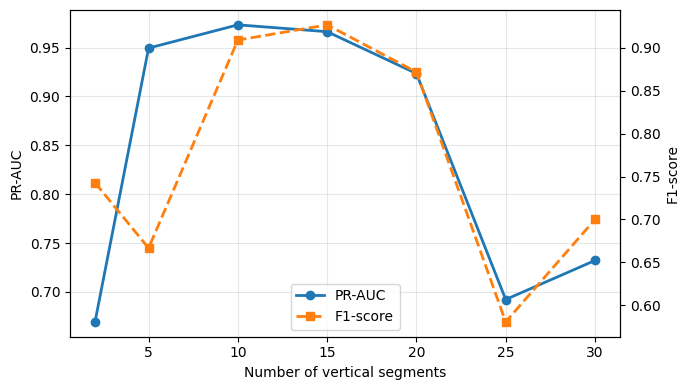

In [ ]:
plot_df = (
    results_df
    .sort_values("segments")
    .drop_duplicates(subset=["segments"])
)

fig, ax1 = plt.subplots(figsize=(7, 4))

# PR-AUC
line1 = ax1.plot(
    plot_df["segments"],
    plot_df["pr_auc"],
    marker="o",
    linewidth=2,
    label="PR-AUC"
)

ax1.set_xlabel("Number of vertical segments")
ax1.set_ylabel("PR-AUC")
ax1.grid(alpha=0.3)

# F1-Score
ax2 = ax1.twinx()

line2 = ax2.plot(
    plot_df["segments"],
    plot_df["f1"],
    marker="s",
    linewidth=2,
    linestyle="--",
    color="tab:orange",
    label="F1-score"
)

ax2.set_ylabel("F1-score")

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc="lower center")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "ver_sensitivity_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
results_df.groupby("top_k")["pr_auc"].agg(["mean", "std"]) 

,mean,std
top_k,,
1,0.843724,0.138463
3,0.843724,0.138463
5,0.843724,0.138463
10,0.843724,0.138463


In [22]:
table_df = (
    results_df[
        ["segments", "top_k", "pr_auc", "f1"]
    ]
    .sort_values("pr_auc", ascending=False)
    .head(6)
)

print(table_df)


    segments  top_k    pr_auc        f1
8         10      1  0.973175  0.909091
9         10      3  0.973175  0.909091
10        10      5  0.973175  0.909091
11        10     10  0.973175  0.909091
15        15     10  0.966191  0.926829
14        15      5  0.966191  0.926829


# Save Results

In [ ]:
results_df.to_csv(
    OUTPUT_DIR / "ver_sensitivity.csv",
    index=False
)

print("Saved:", OUTPUT_DIR / "ver_sensitivity.csv")


Saved: C:\Users\Zeleny\Documents\01_VSCode\spectrogram-anomaly-ae\reports\ver_sensitivity.csv


In [ ]:
pivot = results_df.pivot(
    index="segments",
    columns="top_k",
    values="pr_auc"
)

pivot.to_csv(
    OUTPUT_DIR / "ver_sensitivity_matrix.csv"
)

print(pivot)